**Pipeline per timestamp:**
1. Update moving obstacle positions → compute dynamic risk map
2. Feed (chi, risk_map) into PNOwPINN → get cost-to-go V(x,g)
3. Run A* with V(x,g) as heuristic → get planned path
4. Visualize

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from scipy.ndimage import distance_transform_edt
import sys, os

from models.fno import FNO2d
from models.deepnormMultiGoal import DEEPNORM2dMultiGoal

# A* planner — same path as continuous_risk_mapping.ipynb
heuristics_dir = os.path.abspath("../2D_Neural_Heuristics")
if heuristics_dir not in sys.path:
    sys.path.append(heuristics_dir)
from astar.astar import AStar
from astar.environment_simple import Environment2D
from astar.utilities import drawMap, drawPath2D

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
data_dir = "dataset/synthetic/64x64/"

dist_maps    = np.load(data_dir + "dist_in.npy")
goal_maps    = np.load(data_dir + "goal.npy")
output_maps  = np.load(data_dir + "output.npy")
actual_masks = np.load(data_dir + "mask.npy")

MAP_IDX  = 7
dist_map    = dist_maps[MAP_IDX]
actual_mask = actual_masks[MAP_IDX]
goal_data   = goal_maps[MAP_IDX][::-1] 
gt_output   = output_maps[MAP_IDX]
H, W        = actual_mask.shape

print(f"Map index : {MAP_IDX}")
print(f"Map size  : {H}x{W}")
print(f"Goal (row,col): {goal_data}")

Map index : 7
Map size  : 64x64
Goal (row,col): [ 7 17]


In [3]:
def smooth_chi(mask, dist, smooth_coef=5.0):
    return torch.mul(torch.tanh(dist * smooth_coef), (mask - 0.5)) + 0.5

# ── FNOSDF ──
modelSDF = FNO2d(4, 1, 8, 8, 16).to(device)
try:
    modelSDF.load_state_dict(
        torch.load("./models/FNOSDF/best_model.pt", map_location=device, weights_only=True))
    print("Loaded FNOSDF weights.")
except FileNotFoundError:
    print("FNOSDF weights not found — check path.")
modelSDF.eval()

# PNO w/ PINN
modelPNO = DEEPNORM2dMultiGoal(4, 8, 8, 16, in_channels=2).to(device)
try:
    modelPNO.load_state_dict(
        torch.load("./results/alexm/best_model.pt", map_location=device, weights_only=True))
    print("Loaded PNOwPINN weights.")
except FileNotFoundError:
    print("PNOwPINN weights not found — check path.")
modelPNO.eval()

# ── Pre-compute chi (static, computed once) ──
mask_tensor = torch.tensor(actual_mask, dtype=torch.float
                           ).reshape(1, H, W, 1).to(device)
with torch.no_grad():
    sdf_tensor = modelSDF(mask_tensor)                     # [1,H,W,1]
    chi_tensor = smooth_chi(mask_tensor, sdf_tensor, 5.0)  # [1,H,W,1]

goal_coord = torch.tensor([goal_data], dtype=torch.int).to(device)
cmap       = 1.0 - actual_mask   # A* convention: 1=obstacle

print("Static chi pre-computed. Ready for dynamic planning.")

Loaded FNOSDF weights.
Loaded PNOwPINN weights.
Static chi pre-computed. Ready for dynamic planning.


/var/folders/70/xcmvqsj57kj0hhxl81k3t4s40000gn/T/ipykernel_10170/3767151052.py:31: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1772176411421/work/torch/csrc/utils/tensor_new.cpp:256.)
  goal_coord = torch.tensor([goal_data], dtype=torch.int).to(device)


We use 3 moving obstacles with random initial positions (far from static obstacles) 
and random velocities that change direction periodically.
The static risk from `dist_map` is combined with the dynamic risk from each obstacle.

In [4]:
NUM_OBSTACLES   = 3
TOTAL_STEPS     = 80       # total simulation timesteps
PLAN_INTERVAL   = 3        # re-plan A* every N steps (to save time)
SIGMA_STATIC    = 3.0      # static risk spread
SIGMA_DYNAMIC   = 4.0      # dynamic obstacle risk spread (larger = more influence)
ALPHA_DYNAMIC   = 1.5      # directional bias strength
MIN_CLEARANCE   = 8        # obstacle starts at least this far from static obstacles

DIRECTIONS = np.array([
    [0, 1], [1, 0], [0, -1], [-1, 0],
    [1, 1], [1, -1], [-1, 1], [-1, -1]
])

# Static risk map 
static_risk = np.exp(-(dist_map ** 2) / (2 * SIGMA_STATIC ** 2))
static_risk = (static_risk - static_risk.min()) / (static_risk.max() - static_risk.min())

# pick a free starting cell with enough clearance 
free_cells  = np.argwhere(actual_mask == 1)
dist_values = dist_map[free_cells[:, 0], free_cells[:, 1]]
open_mask   = dist_values >= MIN_CLEARANCE
open_cells  = free_cells[open_mask] if open_mask.any() else free_cells
open_dists  = dist_values[open_mask] if open_mask.any() else dist_values
weights_init = open_dists / open_dists.sum()

def random_start():
    idx = np.random.choice(len(open_cells), p=weights_init)
    return open_cells[idx].copy()

np.random.seed(42)
obs_positions = [random_start() for _ in range(NUM_OBSTACLES)]
obs_velocities = [DIRECTIONS[np.random.choice(len(DIRECTIONS))] for _ in range(NUM_OBSTACLES)]

low_interval  = max(1, int(TOTAL_STEPS * 0.2))
high_interval = max(2, int(TOTAL_STEPS * 0.4))
steps_since   = [0] * NUM_OBSTACLES
change_at     = [np.random.randint(low_interval, high_interval) for _ in range(NUM_OBSTACLES)]

print("Obstacle initial positions:")
for i, p in enumerate(obs_positions):
    print(f"  Obstacle {i+1}: row={p[0]}, col={p[1]}")

Obstacle initial positions:
  Obstacle 1: row=24, col=16
  Obstacle 2: row=41, col=41
  Obstacle 3: row=25, col=24


In [5]:
def compute_dynamic_risk(obs_pos, obs_vel, H, W, sigma, alpha):
    """Compute directional risk map for a single moving obstacle."""
    grid = np.zeros((H, W))
    grid[obs_pos[0], obs_pos[1]] = 1
    dyn_dist = distance_transform_edt(1 - grid)

    xs, ys = np.meshgrid(np.arange(W), np.arange(H))
    dx = xs - obs_pos[1]   # note: obs_pos=[row,col], xs=col-axis
    dy = ys - obs_pos[0]

    vel_norm = np.linalg.norm(obs_vel) + 1e-6
    d_norm   = np.sqrt(dx**2 + dy**2) + 1e-6
    cos_theta = (dx * obs_vel[1] + dy * obs_vel[0]) / (vel_norm * d_norm)

    w = 1 + alpha * cos_theta
    dir_dist  = dyn_dist / w
    risk      = np.exp(-(dir_dist**2) / (2 * sigma**2))
    risk      = (risk - risk.min()) / (risk.max() - risk.min() + 1e-8)
    return risk


def compute_total_risk(obs_positions, obs_velocities, static_risk, H, W):
    """Accumulate static + all dynamic risks, clipped to [0,1]."""
    total = static_risk.copy()
    for pos, vel in zip(obs_positions, obs_velocities):
        dyn = compute_dynamic_risk(pos, vel, H, W, SIGMA_DYNAMIC, ALPHA_DYNAMIC)
        total = np.clip(total + dyn, 0, 1)
    return total


def pno_inference(risk_map_np):
    """Run PNOwPINN with updated risk map. Returns masked cost-to-go as numpy array."""
    risk_t = torch.tensor(risk_map_np, dtype=torch.float
                          ).reshape(1, H, W, 1).to(device)
    with torch.no_grad():
        chi_risk = torch.cat([chi_tensor, risk_t], dim=-1)   # [1,H,W,2]
        cost     = modelPNO(chi_risk, goal_coord)             # [1,H,W,1]
    cost_masked = (cost * mask_tensor).squeeze().cpu().numpy()
    return cost_masked

"""
Pick up the largest cost path, may change the start point
Run A* using cost-to-go as heuristic. Returns path array (may be empty).
def run_astar(cost_map_np):
    env = Environment2D(goal_data, cmap, valuefunction=cost_map_np)
    passable = np.argwhere(cmap == 0)
    valid_costs = [(idx, cost_map_np[idx[0], idx[1]]) for idx in passable]
    valid_costs.sort(key=lambda x: x[1], reverse=True)
    start_coord = valid_costs[0][0]
    _, path, _, nodes_count, _ = AStar.plan(start_coord, env)
    return np.asarray(path), start_coord, nodes_count
"""


AGENT_POS = None   

def run_astar(cost_map_np):
    global AGENT_POS
    env = Environment2D(goal_data, cmap, valuefunction=cost_map_np, risk_weight=5)

    # From the largest cost
    if AGENT_POS is None:
        passable = np.argwhere(cmap == 0)
        valid_costs = [(idx, cost_map_np[idx[0], idx[1]]) for idx in passable]
        valid_costs.sort(key=lambda x: x[1], reverse=True)
        AGENT_POS = valid_costs[0][0]

    _, path, _, nodes_count, _ = AStar.plan(AGENT_POS, env)

    # agent walk
    if len(path) > PLAN_INTERVAL:
        AGENT_POS = np.array(path[PLAN_INTERVAL])  
    elif len(path) > 1:
        AGENT_POS = np.array(path[-1])         

    return np.asarray(path), AGENT_POS, nodes_count


def step_obstacles():
    """Move all obstacles one step, updating velocities randomly."""
    for i in range(NUM_OBSTACLES):
        if steps_since[i] >= change_at[i]:
            opp = (np.argmax([np.dot(obs_velocities[i], d) for d in DIRECTIONS])
                   + len(DIRECTIONS) // 2) % len(DIRECTIONS)
            valid = [j for j in range(len(DIRECTIONS)) if j != opp]
            obs_velocities[i] = DIRECTIONS[np.random.choice(valid)]
            change_at[i]      = np.random.randint(low_interval, high_interval)
            steps_since[i]    = 0

        next_pos = obs_positions[i] + obs_velocities[i]

        # meet the boundary, switch direction
        if next_pos[0] < 0 or next_pos[0] > H - 1:
            obs_velocities[i] = obs_velocities[i] * np.array([-1, 1])
            next_pos[0] = np.clip(next_pos[0], 0, H - 1)

        if next_pos[1] < 0 or next_pos[1] > W - 1:
            obs_velocities[i] = obs_velocities[i] * np.array([1, -1])
            next_pos[1] = np.clip(next_pos[1], 0, W - 1)

        obs_positions[i] = next_pos
        steps_since[i] += 1


def pno_inference_with_risk_penalty(risk_map_np, alpha=15.0):
    """
    baseline cost-to-go + risk penalty
    alpha: impact on the control of risk
    """
    risk_t = torch.tensor(risk_map_np, dtype=torch.float
                          ).reshape(1, H, W, 1).to(device)
    with torch.no_grad():
        chi_risk = torch.cat([chi_tensor, risk_t], dim=-1)
        cost     = modelPNO(chi_risk, goal_coord)
    
    cost_np = (cost * mask_tensor).squeeze().cpu().numpy()
    
    cost_with_penalty = cost_np + alpha * risk_map_np
    
    cost_with_penalty = cost_with_penalty * actual_mask
    
    return cost_with_penalty

In [6]:
# Storage for all frames
frames = []   # each entry: dict with risk_map, cost_map, path, start, obs_positions snapshot

current_cost_map = None
current_path     = np.array([])
current_start    = None
current_nodes    = 0

print(f"Running {TOTAL_STEPS} steps, replanning every {PLAN_INTERVAL} steps...")
print(f"{'Step':>5}  {'Replan':>8}  {'Path len':>10}  {'Nodes':>8}")
print("-" * 38)

for t in range(TOTAL_STEPS):
    # 1. move obstacles
    step_obstacles()

    # 2. compute total risk
    total_risk = compute_total_risk(
        obs_positions, obs_velocities, static_risk, H, W)

    # 3. PNO inference + A* every PLAN_INTERVAL steps
    replan = (t % PLAN_INTERVAL == 0)
    if replan:
        current_cost_map = pno_inference_with_risk_penalty(total_risk)
        current_path, current_start, current_nodes = run_astar(current_cost_map)

    # 4. store frame
    frames.append({
        'step':          t + 1,
        'risk_map':      total_risk.copy(),
        'cost_map':      current_cost_map.copy() if current_cost_map is not None else None,
        'path':          current_path.copy() if len(current_path) > 0 else np.array([]),
        'start':         current_start,
        'nodes':         current_nodes,
        'obs_positions': [p.copy() for p in obs_positions],
        'obs_velocities':[v.copy() for v in obs_velocities],
        'replan':        replan,
    })

    path_len = len(current_path) if len(current_path) > 0 else 0
    print(f"{t+1:>5}  {'YES' if replan else '':>8}  {path_len:>10}  {current_nodes:>8}")

print("\nSimulation complete.")

Running 80 steps, replanning every 3 steps...
 Step    Replan    Path len     Nodes
--------------------------------------
    1       YES          70      1042
    2                    70      1042
    3                    70      1042
    4       YES          67      1225
    5                    67      1225
    6                    67      1225
    7       YES          64      1079
    8                    64      1079
    9                    64      1079
   10       YES          61      1057
   11                    61      1057
   12                    61      1057
   13       YES          58      1080
   14                    58      1080
   15                    58      1080
   16       YES          55      1060
   17                    55      1060
   18                    55      1060
   19       YES          52       969
   20                    52       969
   21                    52       969
   22       YES          50       909
   23                    50       909
   

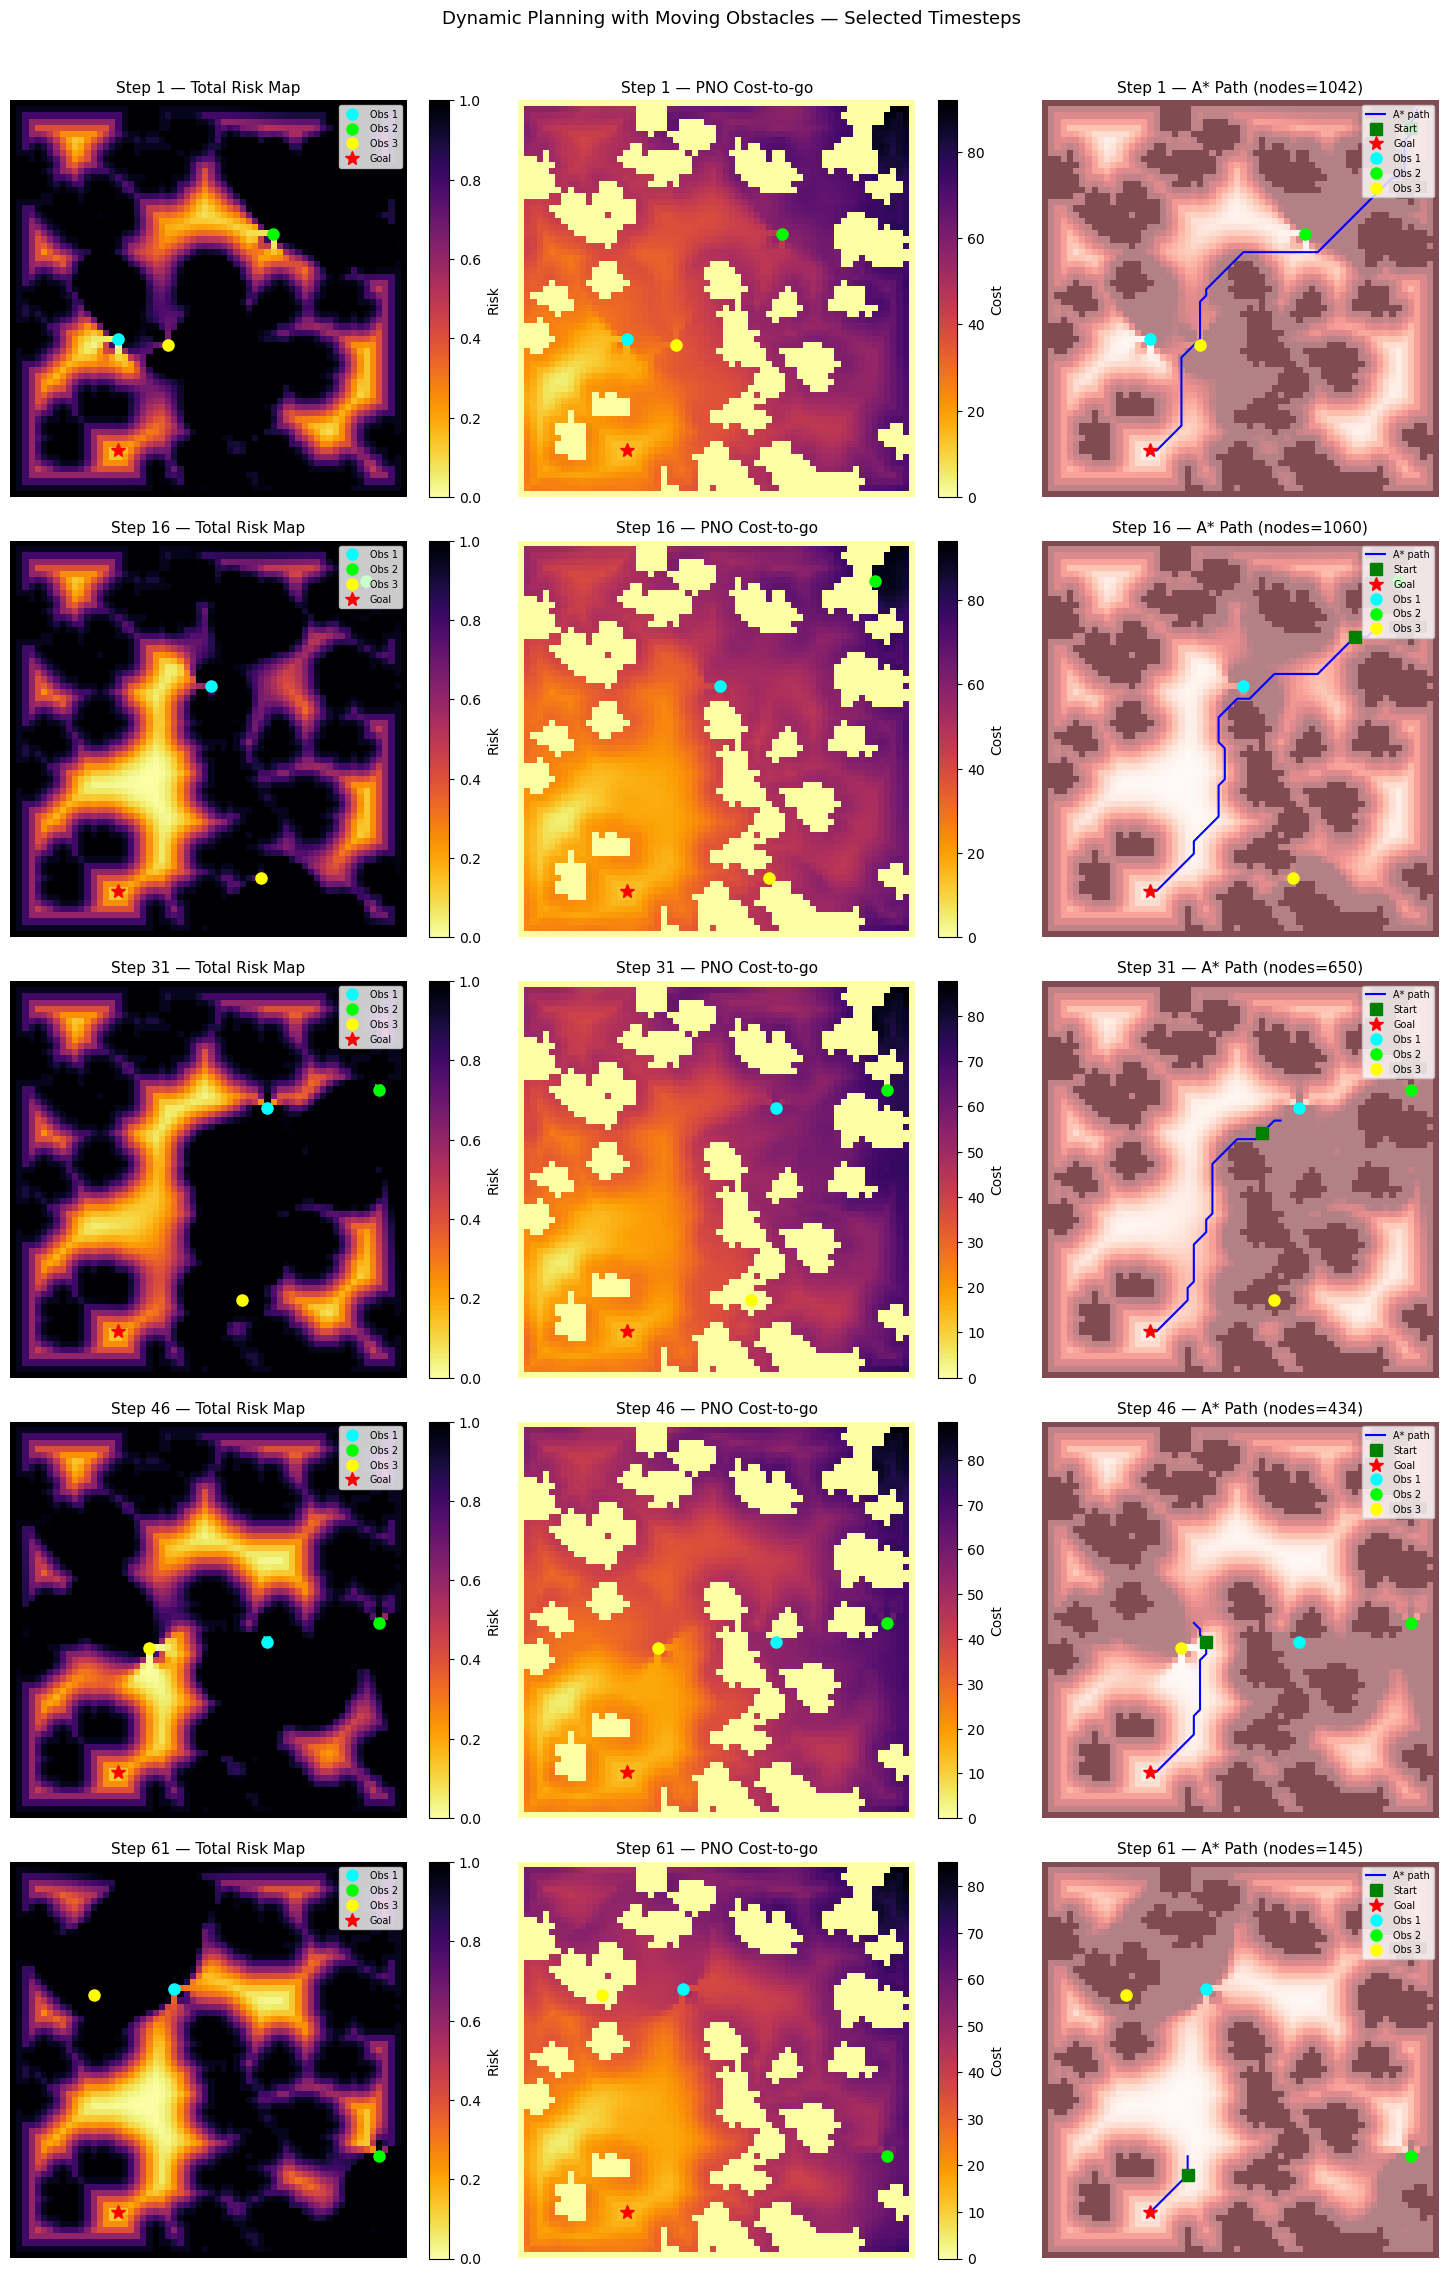

Saved: dynamic_planning_grid.png


In [7]:
dynamic_result_path = "./dynamic_results/"

# Pick frames where replanning happened
replan_frames = [f for f in frames if f['replan']]
# Show at most 5 of them evenly spaced
show_frames = replan_frames[::max(1, len(replan_frames)//5)][:5]

fig, axes = plt.subplots(len(show_frames), 3,
                         figsize=(15, 4.5 * len(show_frames)))
if len(show_frames) == 1:
    axes = axes[None, :]   # ensure 2-D indexing

COLORS = ['cyan', 'lime', 'yellow']   # one colour per obstacle

for row, fr in enumerate(show_frames):
    step         = fr['step']
    risk_map     = fr['risk_map']
    cost_map     = fr['cost_map']
    path         = fr['path']
    obs_pos      = fr['obs_positions']
    obs_vel      = fr['obs_velocities']
    start        = fr['start']

    # ── Col 0: Total Risk Map ──
    ax = axes[row, 0]
    im = ax.imshow(risk_map, origin='lower', cmap='inferno_r', vmin=0, vmax=1)
    fig.colorbar(im, ax=ax, fraction=0.046, label='Risk')
    for i, (pos, vel) in enumerate(zip(obs_pos, obs_vel)):
        ax.plot(pos[1], pos[0], 'o', color=COLORS[i], markersize=8,
                label=f'Obs {i+1}')
        # draw velocity arrow
        ax.annotate('', xy=(pos[1]+vel[1], pos[0]+vel[0]),
                    xytext=(pos[1], pos[0]),
                    arrowprops=dict(arrowstyle='->', color=COLORS[i], lw=1.5))
    ax.plot(goal_data[1], goal_data[0], 'r*', markersize=10, label='Goal')
    ax.set_title(f'Step {step} — Total Risk Map', fontsize=11)
    ax.legend(loc='upper right', fontsize=7)
    ax.axis('off')

    # ── Col 1: Predicted Cost-to-go ──
    ax = axes[row, 1]
    im = ax.imshow(cost_map, origin='lower', cmap='inferno_r')
    fig.colorbar(im, ax=ax, fraction=0.046, label='Cost')
    for i, pos in enumerate(obs_pos):
        ax.plot(pos[1], pos[0], 'o', color=COLORS[i], markersize=8)
    ax.plot(goal_data[1], goal_data[0], 'r*', markersize=10)
    ax.set_title(f'Step {step} — PNO Cost-to-go', fontsize=11)
    ax.axis('off')

    # ── Col 2: A* Path ──
    ax = axes[row, 2]
    ax.imshow(actual_mask, origin='lower', cmap='gray', alpha=0.4)
    ax.imshow(risk_map, origin='lower', cmap='Reds', alpha=0.5, vmin=0, vmax=1)
    if len(path) > 0:
        ax.plot(path[:, 1], path[:, 0], 'b-', linewidth=1.5, label='A* path')
    if start is not None:
        ax.plot(start[1], start[0], 'gs', markersize=8, label='Start')
    ax.plot(goal_data[1], goal_data[0], 'r*', markersize=10, label='Goal')
    for i, pos in enumerate(obs_pos):
        ax.plot(pos[1], pos[0], 'o', color=COLORS[i], markersize=8,
                label=f'Obs {i+1}')
    ax.set_title(f'Step {step} — A* Path (nodes={fr["nodes"]})', fontsize=11)
    ax.legend(loc='upper right', fontsize=7)
    ax.axis('off')

plt.suptitle('Dynamic Planning with Moving Obstacles — Selected Timesteps',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(dynamic_result_path+'dynamic_planning_grid.png', bbox_inches='tight', dpi=120)
plt.show()
print("Saved: dynamic_planning_grid.png")

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── initialise placeholders ──
im_risk = axes[0].imshow(frames[0]['risk_map'], origin='lower',
                          cmap='inferno_r', vmin=0, vmax=1)
fig.colorbar(im_risk, ax=axes[0], fraction=0.046, label='Risk')
axes[0].set_title('Total Risk Map')
axes[0].axis('off')

im_cost = axes[1].imshow(frames[0]['cost_map'], origin='lower', cmap='inferno_r')
fig.colorbar(im_cost, ax=axes[1], fraction=0.046, label='Cost')
axes[1].set_title('PNO Cost-to-go')
axes[1].axis('off')

axes[2].imshow(actual_mask, origin='lower', cmap='gray', alpha=0.4)
im_risk2 = axes[2].imshow(frames[0]['risk_map'], origin='lower',
                            cmap='Reds', alpha=0.5, vmin=0, vmax=1)
path_line,  = axes[2].plot([], [], 'b-', linewidth=1.5, label='A* path')
start_dot,  = axes[2].plot([], [], 'gs', markersize=8, label='Start')
goal_dot    = axes[2].plot(goal_data[1], goal_data[0], 'r*',
                            markersize=10, label='Goal')[0]
obs_dots    = [axes[2].plot([], [], 'o', color=COLORS[i], markersize=8,
                             label=f'Obs {i+1}')[0]
               for i in range(NUM_OBSTACLES)]
axes[2].legend(loc='upper right', fontsize=7)
axes[2].set_title('A* Path Planning')
axes[2].axis('off')

# title artists
suptitle = fig.suptitle('', fontsize=12)

# scatter for obstacle markers on left two panels
obs_scatter_risk = [axes[0].plot([], [], 'o', color=COLORS[i], markersize=7)[0]
                    for i in range(NUM_OBSTACLES)]
obs_scatter_cost = [axes[1].plot([], [], 'o', color=COLORS[i], markersize=7)[0]
                    for i in range(NUM_OBSTACLES)]
goal_risk = axes[0].plot(goal_data[1], goal_data[0], 'r*', markersize=10)[0]
goal_cost = axes[1].plot(goal_data[1], goal_data[0], 'r*', markersize=10)[0]

def update_anim(frame_idx):
    fr = frames[frame_idx]
    risk_map = fr['risk_map']
    cost_map = fr['cost_map']
    path     = fr['path']
    obs_pos  = fr['obs_positions']
    start    = fr['start']

    im_risk.set_data(risk_map)
    im_cost.set_data(cost_map)
    im_risk2.set_data(risk_map)

    for i, pos in enumerate(obs_pos):
        obs_scatter_risk[i].set_data([pos[1]], [pos[0]])
        obs_scatter_cost[i].set_data([pos[1]], [pos[0]])
        obs_dots[i].set_data([pos[1]], [pos[0]])

    if len(path) > 0:
        path_line.set_data(path[:, 1], path[:, 0])
    else:
        path_line.set_data([], [])

    if start is not None:
        start_dot.set_data([start[1]], [start[0]])

    replan_str = ' [REPLAN]' if fr['replan'] else ''
    suptitle.set_text(f"Step {fr['step']}/{TOTAL_STEPS}{replan_str}  |  "
                      f"Path len={len(path)}  Nodes={fr['nodes']}")
    return [im_risk, im_cost, im_risk2, path_line, start_dot,
            *obs_scatter_risk, *obs_scatter_cost, *obs_dots, suptitle]

ani = FuncAnimation(fig, update_anim, frames=len(frames),
                    interval=400, blit=True)
ani.save(dynamic_result_path+'dynamic_planning.gif', writer='pillow', fps=3)
plt.close()
print("Saved: dynamic_planning.gif")

Saved: dynamic_planning.gif


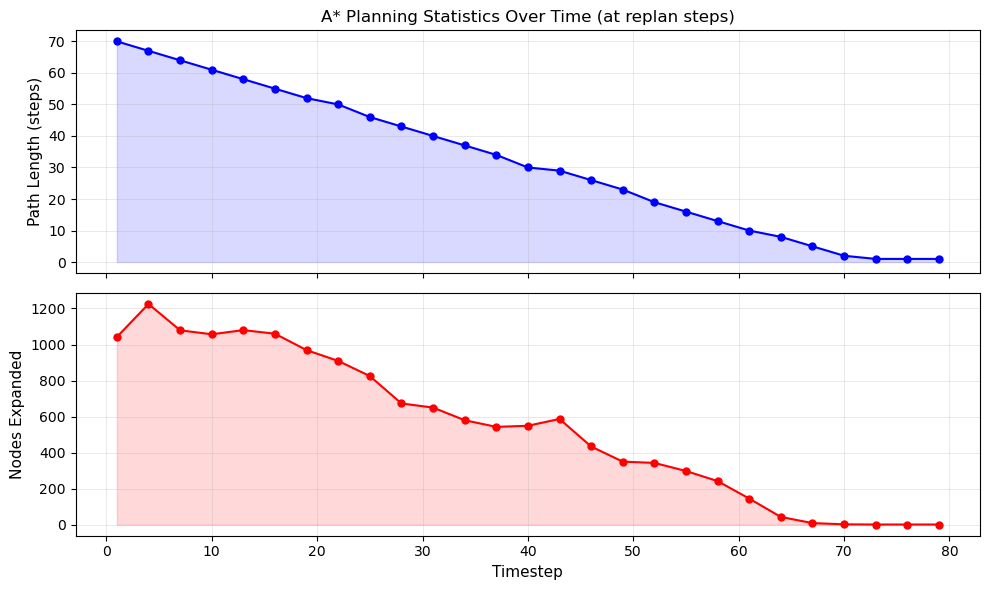

Saved: planning_statistics.png

Summary over 27 replan steps:
  Avg path length : 31.9
  Avg nodes expanded: 544.3


In [9]:
replan_steps  = [f['step']  for f in frames if f['replan']]
path_lengths  = [len(f['path']) for f in frames if f['replan']]
nodes_counts  = [f['nodes'] for f in frames if f['replan']]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(replan_steps, path_lengths, 'b-o', markersize=5, linewidth=1.5)
ax1.set_ylabel('Path Length (steps)', fontsize=11)
ax1.set_title('A* Planning Statistics Over Time (at replan steps)', fontsize=12)
ax1.grid(True, alpha=0.4)
ax1.fill_between(replan_steps, path_lengths, alpha=0.15, color='blue')

ax2.plot(replan_steps, nodes_counts, 'r-o', markersize=5, linewidth=1.5)
ax2.set_ylabel('Nodes Expanded', fontsize=11)
ax2.set_xlabel('Timestep', fontsize=11)
ax2.grid(True, alpha=0.4)
ax2.fill_between(replan_steps, nodes_counts, alpha=0.15, color='red')

plt.tight_layout()
plt.savefig(dynamic_result_path+'planning_statistics.png', bbox_inches='tight', dpi=120)
plt.show()
print("Saved: planning_statistics.png")

print(f"\nSummary over {len(replan_steps)} replan steps:")
print(f"  Avg path length : {np.mean(path_lengths):.1f}")
print(f"  Avg nodes expanded: {np.mean(nodes_counts):.1f}")